- 실제 주가 데이터 불러오기
- 수익률과 이동평균 변수 생성
- 다음 날 상승 여부 라벨 만들기
- 지도학습 분류모델 학습
- 정확도 평가
- 간단한 예측 결과 확인

In [1]:
from pykrx import stock
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

C:\Users\JYB\AppData\Local\Programs\Python\Python39\lib\site-packages\pykrx\__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


### 1. 삼성전자 주가 데이터 불러오기

In [2]:
df = stock.get_market_ohlcv(
    fromdate="20240101",
    todate="20260731",
    ticker="005930"
)

print(df.head())

               시가     고가     저가     종가       거래량       등락률
날짜                                                        
2024-01-02  78200  79800  78200  79600  17142847  1.401274
2024-01-03  78500  78800  77000  77000  21753644 -3.266332
2024-01-04  76100  77300  76100  76600  15324439 -0.519481
2024-01-05  76700  77100  76400  76600  11304316  0.000000
2024-01-08  77000  77500  76400  76500  11088724 -0.130548


### 2.입력변수 만들기

In [3]:
df["수익률"] = df["종가"].pct_change() * 100

df["거래량변화율"] = df["거래량"].pct_change() * 100

df["5일이동평균"] = df["종가"].rolling(window=5).mean()
df["20일이동평균"] = df["종가"].rolling(window=20).mean()

df["이동평균차이"] = (
    df["5일이동평균"] - df["20일이동평균"]
) / df["20일이동평균"] * 100

print(df.head())

               시가     고가     저가     종가       거래량       등락률       수익률  \
날짜                                                                     
2024-01-02  78200  79800  78200  79600  17142847  1.401274       NaN   
2024-01-03  78500  78800  77000  77000  21753644 -3.266332 -3.266332   
2024-01-04  76100  77300  76100  76600  15324439 -0.519481 -0.519481   
2024-01-05  76700  77100  76400  76600  11304316  0.000000  0.000000   
2024-01-08  77000  77500  76400  76500  11088724 -0.130548 -0.130548   

               거래량변화율   5일이동평균  20일이동평균  이동평균차이  
날짜                                               
2024-01-02        NaN      NaN      NaN     NaN  
2024-01-03  26.896332      NaN      NaN     NaN  
2024-01-04 -29.554612      NaN      NaN     NaN  
2024-01-05 -26.233411      NaN      NaN     NaN  
2024-01-08  -1.907165  77260.0      NaN     NaN  


### 3. 정답 라벨 만들기

- 다음 날 수익률이 0보다 크면 상승으로 정의한다.

In [4]:
df["다음날수익률"] = df["수익률"].shift(-1)

df["다음날상승"] = (
    df["다음날수익률"] > 0
).astype(int)

df = df.dropna()

print(df[["수익률", "거래량변화율", "이동평균차이", "다음날상승"]].head())

                 수익률     거래량변화율    이동평균차이  다음날상승
날짜                                              
2024-01-29  1.362398  25.236948 -0.442656      0
2024-01-30 -0.134409 -12.392948 -0.329811      0
2024-01-31 -2.153432  28.250767 -0.391522      1
2024-02-01  1.237964  26.602076 -0.324675      1
2024-02-02  2.173913 -24.773119  0.257278      0


### 4. 입력 X와 정답 y 분리

In [5]:
X = df[
    ["수익률", "거래량변화율", "이동평균차이"]
]

y = df["다음날상승"]

print(X.head())
print(y.head())

                 수익률     거래량변화율    이동평균차이
날짜                                       
2024-01-29  1.362398  25.236948 -0.442656
2024-01-30 -0.134409 -12.392948 -0.329811
2024-01-31 -2.153432  28.250767 -0.391522
2024-02-01  1.237964  26.602076 -0.324675
2024-02-02  2.173913 -24.773119  0.257278
날짜
2024-01-29    0
2024-01-30    0
2024-01-31    1
2024-02-01    1
2024-02-02    0
Name: 다음날상승, dtype: int32


### 5. 학습 데이터와 평가 데이터 분리

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    shuffle=False
)

print("학습 데이터 크기:", X_train.shape)
print("평가 데이터 크기:", X_test.shape)

학습 데이터 크기: (425, 3)
평가 데이터 크기: (183, 3)


### 6. 표준화

In [ ]:
# 표준화 이유:
# 변수 단위 차이를 줄인다.
# 모델 학습을 안정적으로 만든다.
# 수익률과 거래량변화율의 스케일 차이를 조정한다.

In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

### 7. 로지스틱 회귀 모델 학습

In [8]:
model = LogisticRegression()

model.fit(X_train_scaled, y_train)

LogisticRegression()

In [ ]:
# 로지스틱 회귀는 분류모델이다.
# 출력값:
# 다음 날 상승확률
# 다음 날 하락확률

### 8. 예측과 평가

In [9]:
y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)

print("정확도:", round(accuracy, 4))

print(classification_report(y_test, y_pred))

정확도: 0.5027
              precision    recall  f1-score   support

           0       0.45      0.46      0.46        82
           1       0.55      0.53      0.54       101

    accuracy                           0.50       183
   macro avg       0.50      0.50      0.50       183
weighted avg       0.50      0.50      0.50       183



### 9. 상승확률 확인

In [10]:
pred_probability = model.predict_proba(X_test_scaled)

result = pd.DataFrame({
    "실제값": y_test.values,
    "예측값": y_pred,
    "하락확률": pred_probability[:, 0],
    "상승확률": pred_probability[:, 1]
}, index=y_test.index)

print(result.head(10))

            실제값  예측값      하락확률      상승확률
날짜                                      
2025-10-31    1    1  0.491412  0.508588
2025-11-03    0    0  0.533949  0.466051
2025-11-04    0    1  0.427708  0.572292
2025-11-05    0    1  0.426642  0.573358
2025-11-06    0    1  0.495407  0.504593
2025-11-07    1    1  0.499909  0.500091
2025-11-10    1    0  0.541812  0.458188
2025-11-11    0    0  0.542187  0.457813
2025-11-12    0    0  0.529276  0.470724
2025-11-13    0    0  0.512213  0.487787


### 10. 예측 결과 시각화

- 로지스틱 회귀모형이 예측한 "다음 날 주가가 상승할 확률"을 날짜별로 나타낸 그래프입니다.

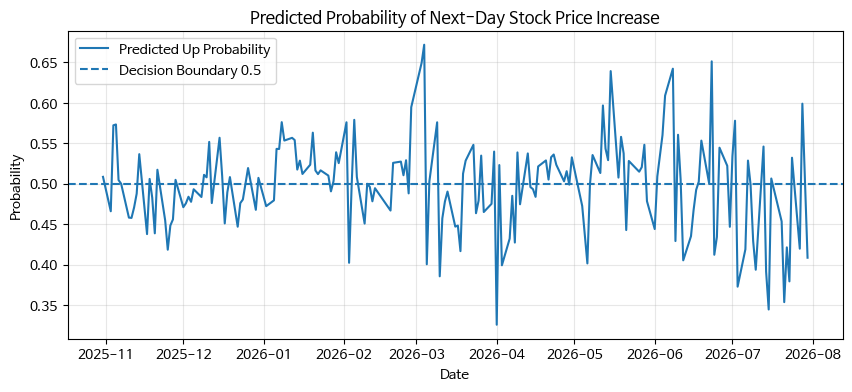

In [11]:
plt.figure(figsize=(10, 4))

plt.plot(
    result.index,
    result["상승확률"],
    label="Predicted Up Probability"
)

plt.axhline(
    0.5,
    linestyle="--",
    label="Decision Boundary 0.5"
)

plt.title("Predicted Probability of Next-Day Stock Price Increase")
plt.xlabel("Date")
plt.ylabel("Probability")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
# (1) 대부분 0.5 이상0.80.70.6계속 유지된다면 모델은 시장을 상승장으로 판단하고 있습니다.
# (2) 대부분 0.5 이하0.30.20.1이라면모델은 하락 가능성이 높다고 판단한 것입니다.

### 11. 회귀계수 확인

In [12]:
coef_df = pd.DataFrame({
    "변수": X.columns,
    "회귀계수": model.coef_[0]
})

print(coef_df)

       변수      회귀계수
0     수익률 -0.079677
1  거래량변화율  0.075680
2  이동평균차이  0.079950


In [ ]:
# 해석:
# 회귀계수가 양수이면 해당 변수가 증가할수록 상승확률이 높아지는 방향
# 회귀계수가 음수이면 해당 변수가 증가할수록 상승확률이 낮아지는 방향